## Tarea 6: Desafío Regresion Lineal

### Resumen del trabajo

Este trabajo estudiará un dataset público de Kaggle que cubre varios datos sobre pacientes con accidentes cerebrovasculares.

Se entrenará un modelo de regresión lineal para verificar correlaciones entre la ocurrencia de un accidente cerebrovascular con factores como enfermedad cardiovascular, nivel de glucosa, IMC, si fuma o no, etc. usando variables dummy. 


Dataset usado:

https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset


#### Instalación de librerías y dataset

In [79]:
!pip install stats
!pip install matplotlib
!pip install kagglehub

In [80]:
import kagglehub
import pandas as pd
import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# descargar a la misma carpeta:
kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset", output_dir='.')

'.'

In [81]:
# Transformar a dataframe

df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Podemos ver que el dataset tiene las siguientes variables:<br>
**gender**: Género del paciente, string (Male, female, other) <br>
**hypertension**: Indicador booleano de si el paciente tiene hipertensión o no<br>
**heart_disease**: Indicador booleano de si el paciente tiene una condición cardiovascular<br>
**smoking_history**: Indicador de si el paciente ha fumado en el pasado, string<br>
**bmi**: Valor IMC<br>
**HbA1c_level**: Nivel de hemoglobina A1c, mide el promedio de glucosa en la sangre en los ultimos 3 meses al examen.<br>
**blood_glucose_level**: Nivel de glucosa en el paciente en el *momento del examen*. <br>
**diabetes**: Variable a predecir. Indica si el paciente tiene diabetes o no.<br>

La variable a predecir sera la variable "diabetes".

In [82]:
faltantes = df.isna().sum()
display(faltantes)
# No tenemos valores nulos!

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [83]:
print(df.dtypes)
df.describe().T # describe las variables numericas

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


Existen varias variables categoricas. Estas seran transformadas antes de entrenar el modelo. 

Podemos además presentar la distribución de valores en la variable objetivo, además de entregar un análisis inicial para encontrar candidatos a posibles correlaciones 

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_2816\1736758096.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


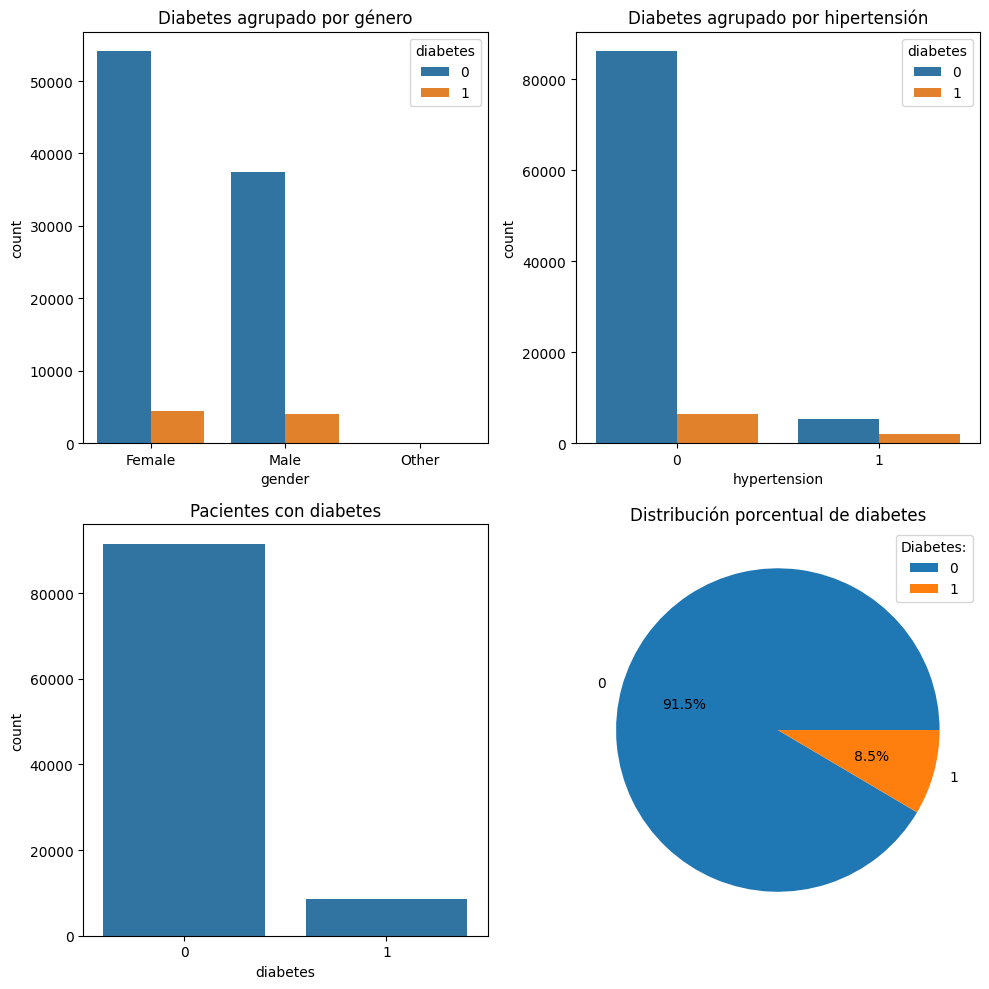

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

ax = sns.countplot(ax=axes[0, 0], x='gender', hue='diabetes', data=df)
axes[0, 0].set_title('Diabetes agrupado por género')

ax = sns.countplot(ax=axes[0, 1], x='hypertension', hue='diabetes', data=df)
axes[0, 1].set_title('Diabetes agrupado por hipertensión')

ax = sns.countplot(ax=axes[1, 0], x='diabetes', data=df)
axes[1, 0].set_title('Pacientes con diabetes')

diabetes_counts = df['diabetes'].value_counts()
axes[1, 1].pie(diabetes_counts, labels=diabetes_counts.index, autopct='%1.1f%%')
axes[1, 1].legend(title='Diabetes:', loc='upper right')
axes[1, 1].set_title('Distribución porcentual de diabetes')

fig.tight_layout()
fig.show()

In [85]:
duplicados = df.duplicated().sum()
print("Registros duplicados:", duplicados)
if duplicados > 0:
    df = df.drop_duplicates()
    print("Duplicados eliminados.")

Registros duplicados: 3854
Duplicados eliminados.


Con esto eliminamos todos los datos duplicados.

In [86]:
print(df.nunique())

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64


No tenemos un problema aparente con la cantidad de valores unicos en las variables cualitativas, por lo que podemos dejar el dataset así mismo.

In [87]:
correlaciones = df.select_dtypes(include=["float64","int64"]).corr()
correlaciones

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317,0.264927
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834,0.195710
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832,0.170711
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543,0.214932
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615,0.406408
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000,0.424336
diabetes,0.264927,0.195710,0.170711,0.214932,0.406408,0.424336,1.000000


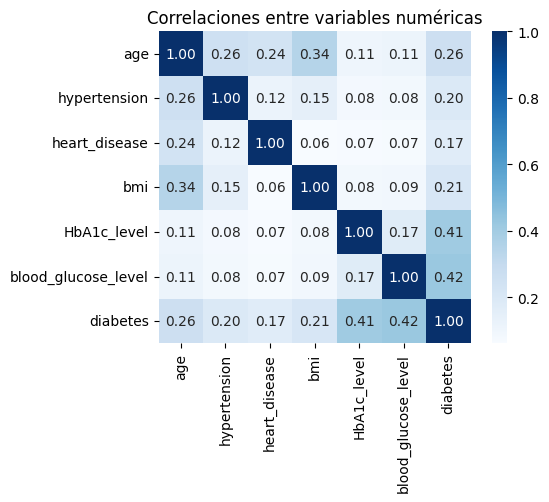

In [88]:
plt.figure(figsize=(6,5))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title('Correlaciones entre variables numéricas')
plt.tight_layout()
plt.show()

Vemos que hay una correlación relativamente alta entre glucosa y diabetes... lo cual tiene sentido! Pero también veremos si hay una correlación entre algunas de las variables cualitativas que transformaremos en variables dummy. (En este caso, solo smoking_history)

In [89]:
obj = 'diabetes'
y = df[obj]
X = df.drop(columns=[obj])
print("Columnas predictoras:", list(X.columns))

Columnas predictoras: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [90]:
X_transformado = pd.get_dummies(X, drop_first=True) # drop_first va a sacar gender_female, pero eso es porque estamos calculando male y other con respecto a female 
print("Total de columnas con dummies:", X_transformado.shape[1]) 
print(X_transformado.columns)

Total de columnas con dummies: 13
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


Entonces, tenemos 13 columnas luego de hacer las columnas dummies.

Ya hemos hecho algunos gráficos, pero ahora que tenemos el estado de fumador de los pacientes, podemos hacer otros gráficos:

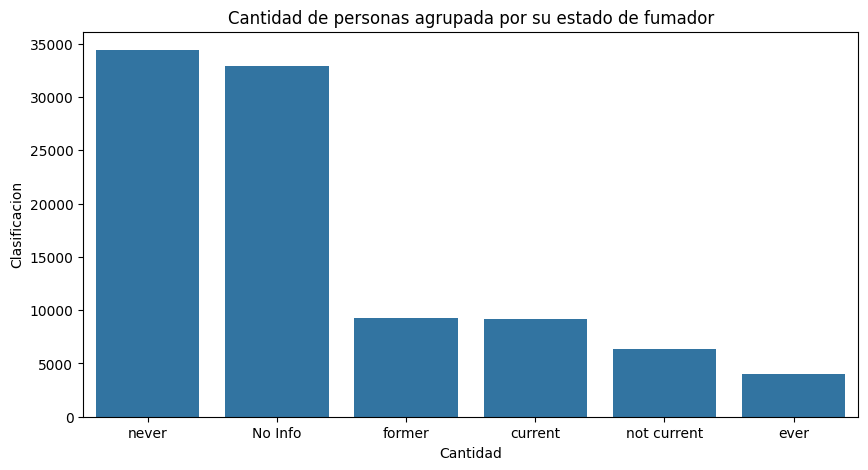

In [91]:
smokeStatusCount = df['smoking_history'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=smokeStatusCount.index, y=smokeStatusCount.values)
plt.xlabel('Cantidad')
plt.ylabel('Clasificacion')
plt.title('Cantidad de personas agrupada por su estado de fumador')
plt.show()

Sería bueno explicar estos valores: <br>

never: El paciente nunca ha fumado. <br>
No Info: ..No hay información del estado de fumador del paciente. <br>
former: El paciente fumaba anteriormente (consistentemente). <br>
current: El paciente es un fumador activo. <br>
not current: El paciente no es un fumador activo. <br>
ever: El paciente ha fumado alguna vez en su vida. <br>


In [92]:
from sklearn.model_selection import train_test_split

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X_transformado,
    y,
    test_size=0.2,
    random_state=42 # Se usa un split 80/20 como visto en clases 
 )
print("Filas de Entrenamiento:", X_entrenamiento.shape[0])
print("Filas de Prueba:", X_prueba.shape[0]) 

Filas de Entrenamiento: 76916
Filas de Prueba: 19230


Lo siguiente sería entrenar el modelo de regresión lineal mediante SFFS. Para esto, necesitaremos:
- Lista de variables disponibles
- Lista de variables seleccionadas
- Historial de MAE (error absoluto medio)

El MAE es una medida de precisión de modelos de regresión lineal que calcula el promedio (medio, mean) de error entre valores predecidos y valores actuales.

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Inicializar estructuras para SFFS:
variables_disponibles = list(X_entrenamiento.columns) # lista de variables disponibles para el entrenamiento
variables_seleccionadas = []
historial_mae = []

iteracion = 0
while variables_disponibles:
    iteracion += 1
    mejor_variable = None
    mejor_mae = float("inf")
    for variable in variables_disponibles:
        columnas_actuales = variables_seleccionadas + [variable]
        modelo = LinearRegression()
        modelo.fit(X_entrenamiento[columnas_actuales], y_entrenamiento)
        pred = modelo.predict(X_prueba[columnas_actuales])
        mae = mean_absolute_error(y_prueba, pred) # Calcular mean absolute error
        if mae < mejor_mae:
            mejor_mae = mae
            mejor_variable = variable
    variables_seleccionadas.append(mejor_variable)
    variables_disponibles.remove(mejor_variable)
    historial_mae.append({"paso": iteracion, "mae": mejor_mae, "variable": mejor_variable})
    print(f"Paso {iteracion}: {mejor_variable} - MAE {mejor_mae:.4f}")

Paso 1: hypertension - MAE 0.1559
Paso 2: heart_disease - MAE 0.1525
Paso 3: bmi - MAE 0.1507
Paso 4: smoking_history_former - MAE 0.1506
Paso 5: gender_Male - MAE 0.1506
Paso 6: smoking_history_ever - MAE 0.1506
Paso 7: gender_Other - MAE 0.1506
Paso 8: smoking_history_not current - MAE 0.1507
Paso 9: smoking_history_current - MAE 0.1508
Paso 10: smoking_history_never - MAE 0.1517
Paso 11: age - MAE 0.1574
Paso 12: blood_glucose_level - MAE 0.1605
Paso 13: HbA1c_level - MAE 0.1581


Algo que vemos aca es que el MAE en verdad no cambio mucho para nada. El modelo tiene una cantidad muy grande de datos de entrenamiento y por eso, no existe mucho error posible.

In [94]:
resultados_sffs = pd.DataFrame(historial_mae)
resultados_sffs

,paso,mae,variable
0,1,0.155863,hypertension
1,2,0.152538,heart_disease
2,3,0.150712,bmi
3,4,0.150628,smoking_history_former
4,5,0.150582,gender_Male
5,6,0.150580,smoking_history_ever
6,7,0.150581,gender_Other
7,8,0.150650,smoking_history_not current
8,9,0.150764,smoking_history_current
9,10,0.151684,smoking_history_never


Podemos modificar el modelo para usar menos variables:

In [95]:
columnasSeleccionadas = [
    'hypertension', 'heart_disease', 'bmi', 'age', 
    'blood_glucose_level', 'HbA1c_level',
    'smoking_history_never', 'smoking_history_former', 'smoking_history_current'
]

modelo_mod = LinearRegression()
modelo_mod.fit(X_entrenamiento[columnasSeleccionadas], y_entrenamiento)

predicciones = modelo_mod.predict(X_prueba[columnasSeleccionadas])
mae_mod = mean_absolute_error(y_prueba, predicciones)

print(f"MAE final con variables seleccionadas: {mae_mod:.4f}")


MAE final con variables seleccionadas: 0.1581


El MAE sigue siendo bajo, pero no importa, veremos que mas podemos hacer.

Veamos que tan preciso es:

In [103]:
from sklearn.metrics import r2_score

r2_prueba = r2_score(y_prueba, predicciones)
r2_prueba

df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


No muy preciso... Veamos nuevamente la matriz de correlacion, con las variables dummies incluidas:

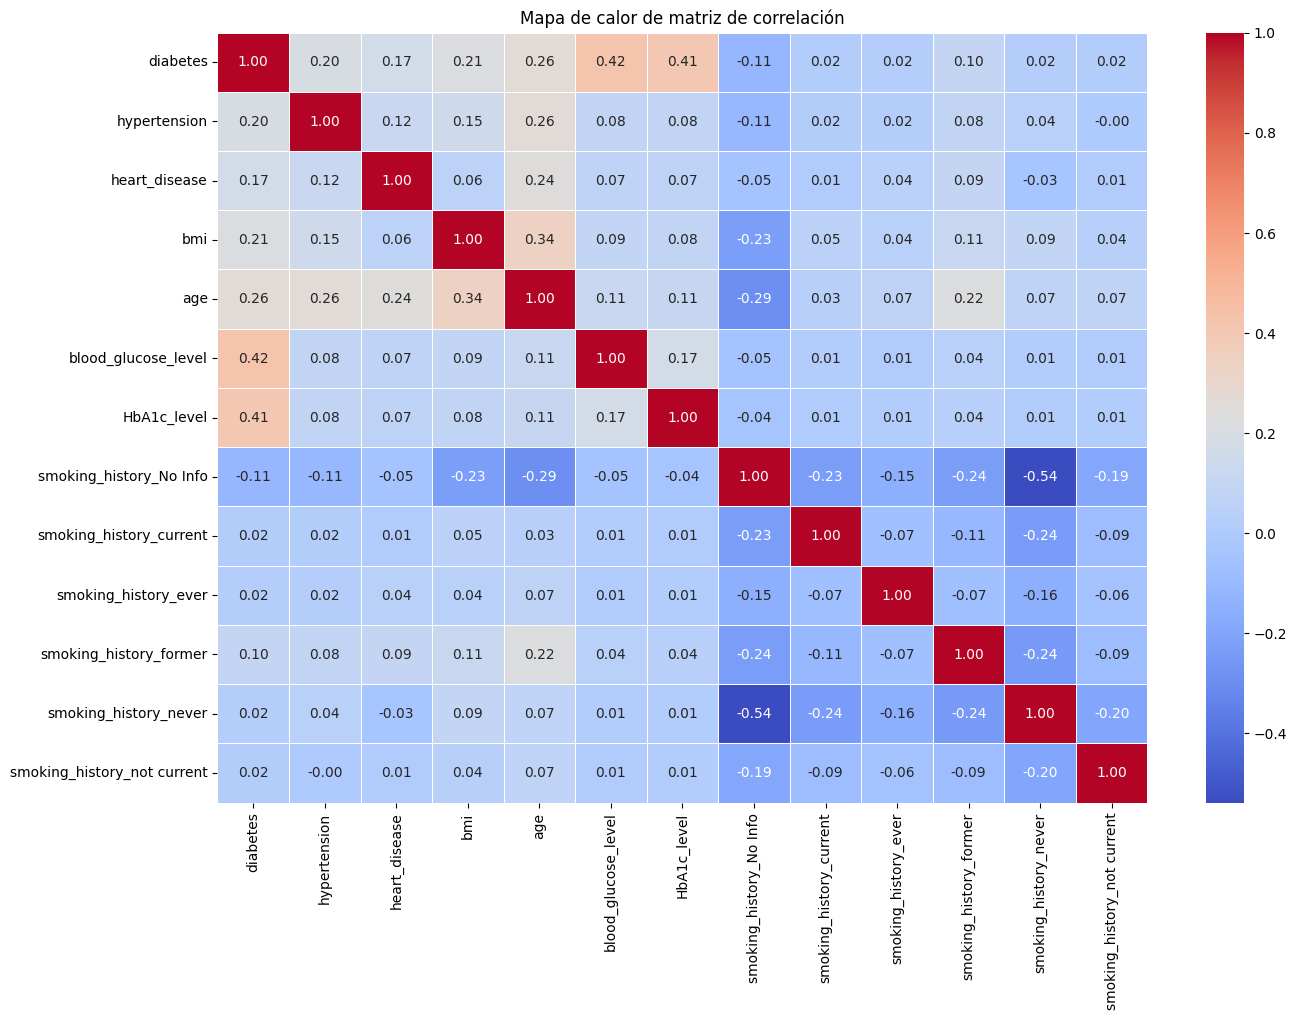

In [105]:
dfDummies = pd.get_dummies(df[['diabetes','hypertension', 'heart_disease', 'bmi', 'age', 
    'blood_glucose_level', 'HbA1c_level',
    'smoking_history']])
plt.figure(figsize=(15, 10))
sns.heatmap(dfDummies.corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Mapa de calor de matriz de correlación")
plt.show()

Vemos acá nuevamente que la correlación es mas alta con glucosa y HbA1c, como esperabamos. Los demas son malos predictores, y por eso, nuestro R2 no es muy bueno.

Lógicamente, deberían ser mejores predictores, no?

Sin embargo, medicamentos para diabetes pueden bajar tu glucosa y nivel HbA1C, por lo tanto, genera positivos en la columna diabetes con una baja glucosa y nivel HbA1C. Eso es lo que pienso y lo que he encontrado.

Dicho todo esto... Comparemos las formas de regresión lineal!

In [116]:
import time
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


columnasSeleccionadas = [
    'hypertension', 'heart_disease', 'bmi', 'age', 
    'blood_glucose_level', 'HbA1c_level',
    'smoking_history_never', 'smoking_history_former', 'smoking_history_current'
]
timeLRstart = time.time()
modelo_finalLR = LinearRegression()
modelo_finalLR.fit(X_entrenamiento[columnasSeleccionadas], y_entrenamiento)
prediccionesLR = modelo_finalLR.predict(X_prueba[columnasSeleccionadas])
timeLRend = time.time()
timeLR = timeLRend - timeLRstart

timeRidgeStart = time.time()
modelo_finalRidge = Ridge(alpha=0.01)
modelo_finalRidge.fit(X_entrenamiento[columnasSeleccionadas], y_entrenamiento)
prediccionesRidge = modelo_finalRidge.predict(X_prueba[columnasSeleccionadas])
timeRidgeEnd = time.time()
timeRidge = timeRidgeEnd - timeRidgeStart

timeLassoStart = time.time()
modelo_finalLasso = Lasso(alpha=0.01)
modelo_finalLasso.fit(X_entrenamiento[columnasSeleccionadas], y_entrenamiento)
prediccionesLasso = modelo_finalLasso.predict(X_prueba[columnasSeleccionadas])
timeLassoEnd = time.time()
timeLasso = timeLassoEnd - timeLassoStart


# Funcion para obtener MAE, R2, Tiempo
def get_metrics(y_true, y_pred, time_taken):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Time": time_taken
    }


res_lr = get_metrics(y_prueba, prediccionesLR, timeLR)
res_ridge = get_metrics(y_prueba, prediccionesRidge, timeRidge)
res_lasso = get_metrics(y_prueba, prediccionesLasso, timeLasso)

results_df = pd.DataFrame([res_lr, res_ridge, res_lasso], 
                          index=['Linear', 'Ridge', 'Lasso'])
display(results_df)




,MAE,R2,Time
Linear,0.158132,0.353486,0.036992
Ridge,0.158132,0.353486,0.027333
Lasso,0.158220,0.340434,0.098958
